# Connor Maul, EID CSM3665

# Section 1: Introduction & System Selection
For this project I chose option D, the mechanical system with high damping, which models an overdamped spring-mass system. It has a very high damping relative to the spring constant, causing it to respond almost instantaneously to internal forces. It is governed by the ODE $\frac{dx}{dt} = -5000x + 0.002 \sin(t)$, where $k$ is the spring constant, $x$ is the distance from the equilibrium point, and $t$ is time. There is initial codition $x(0)=1m$, meaning at time zero the mass is 1 meter away from its equilibrium point. In $-5000x$. This system is important to high performance shock absorbers, vibration dampers, and seismic isolation, used to supress high-frequency vibrations while following the general path of a lower-frequency input.

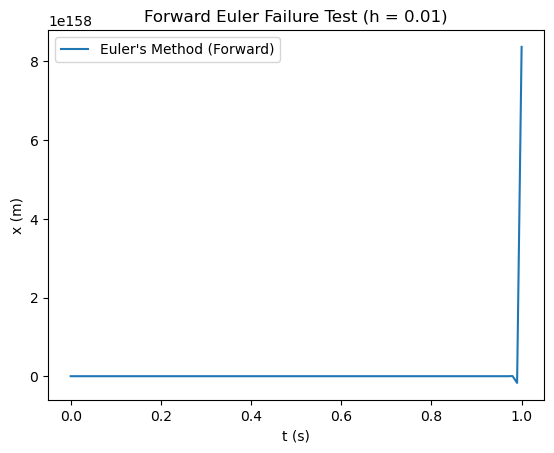

In [19]:
import numpy as np
import matplotlib.pyplot as plt

#create the function for the ODE
def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)

#function for the forward euler method
def euler_method(f, x0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros(len(t_values))
    x_values[0] = x0

    for i in range(1, len(t_values) - 1):
        x_values[i + 1] = x_values[i] + h * f(t_values[i], x_values[i])

    return t_values, x_values

t_vals, x_vals = euler_method(f, 1.0, 0.0, 1.0, 0.01)

#Plot the results
plt.plot(t_vals, x_vals, label="Euler's Method (Forward)")
plt.xlabel('t (s)')
plt.ylabel('x (m)')
plt.title("Forward Euler Failure Test (h = 0.01)")
plt.legend()
plt.show()

# Section 2: Demonstration of Stiffness
Solving this system with Euler's method is unstable, with the estimate shooting up unreasonably high near $t=1$ even with a small step size of $h=0.01$. The stiffness ratio for the system is 5000, derived from the ratio of the eigenvalue $\lambda = 5000$ to the frequency of the driving force $\omega = 1$. This means the internal transient state settles 5,000 times faster than the external signal changes. The step size for euler's method would need to be $h < 0.0004$ to satisfy the stability requirment of $h < 2/|\lambda|$, making it impractical, meaning implicit methods are necessary.

# Section 3: Mathematical Setup
The residual function for my problem is $g(x_{n+1}) = x_{n+1} - x_n - h(-5000x_{n+1} + 0.002 \sin(t_{n+1}))$.

The analytical derivation is $g'(x_{n+1}) = \frac{d}{dx_{n+1}} [x_{n+1} - x_n - h(-5000x_{n+1} + 0.002 \sin(t_{n+1}))]$, which results in $g'(x_{n+1}) = 1 - h(-5000) = 1 + 5000h$.

The specific Newton-Raphson update formula for my problem is $x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{x_{n+1}^{(k)} - x_n - h(-5000x_{n+1}^{(k)} + 0.002 \sin(t_{n+1}))}{1 + 5000h}$.

In [24]:
#Section 4 code
#Code adapted from live coding lecture
#Constants for this system
LAMBDA = 5000

def residual(x_next, x_n, t_next, h):
    #g(x_{n+1}) = x_{n+1} - x_n - h*f(t_{n+1}, x_{n+1})
    return x_next - x_n - h * f(t_next, x_next)

def residual_derivative(h):
    #g'(x_{n+1}) = 1 + lambda*h
    return 1 + LAMBDA * h

def newton_raphson_step(x_n, t_next, h, tol=1e-8, max_iter=20):
    #Solves for x_{n+1} using Newton-Raphson iteration
    x_guess = x_n + h * f(t_next - h, x_n)  #Using explicit Euler predictor as initial guess
    g_prime = residual_derivative(h)
    
    for k in range(max_iter):
        g = residual(x_guess, x_n, t_next, h)
        if abs(g) < tol:
            return x_guess, k
        
        # Update step
        x_guess = x_guess - g / g_prime
        
    return x_guess, max_iter

#creates solution using implicit euler method
def euler_backward(x0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros(len(t_values))
    iters = np.zeros(len(t_values)-1)
    x_values[0] = x0
    
    for n in range(len(t_values) - 1):
        x_next, k = newton_raphson_step(x_values[n], t_values[n+1], h)
        x_values[n+1] = x_next
        iters[n] = k
        
    return t_values, x_values, iters

# Section 4: Implementation
The residual function represents $g(x_{n+1})$. Because my system is linear, the derivative $g'(x_{n+1})$ is a constant $(1 + 5000h)$, so residual_derivative() calcualtes this value once per step size rather than every step in the NR loop. newton_raphson_step() takes the curren state $x_n$ and an inital guess to find the root of the residual equation within a max number of iterations and tolerence. euler_backward() iterates through the time array, calling the newton raphson method at each step to determine the next state, also tracking and returning the number of times required for NR to converge.

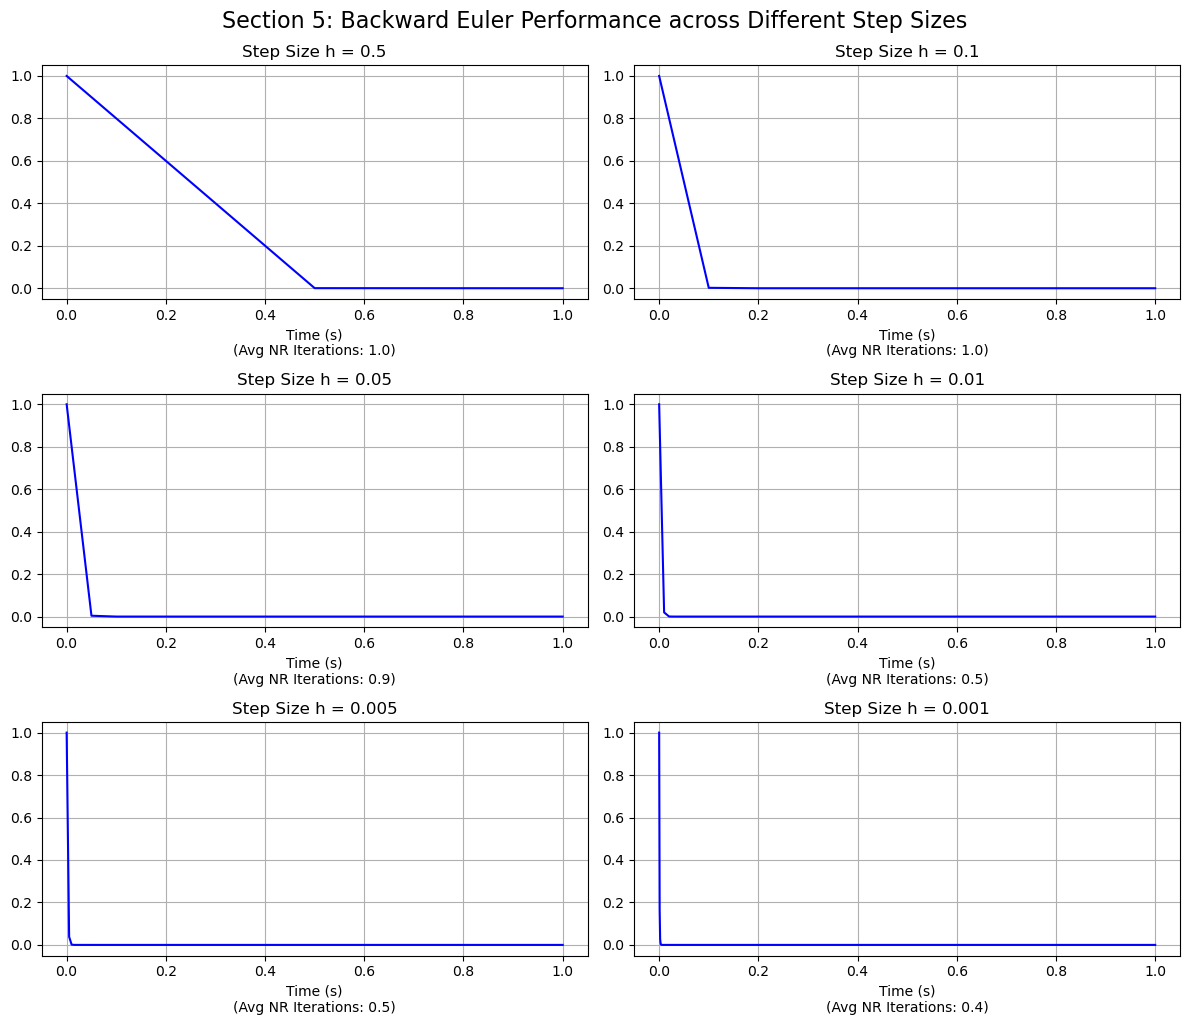

In [25]:
#Section 5 code
#Test with a large step size (h = 0.1) where Forward Euler failed
h_values = [0.5, 0.1, 0.05, .01, .005, .001]

fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

for i, h in enumerate(h_values):
    #Run the Backward Euler simulation
    t_imp, x_imp, nr_iters = euler_backward(x0=1.0, t0=0.0, tf=1.0, h=h)
    
    #Plotting on the specific subplot
    axes[i].plot(t_imp, x_imp, 'b-', label=f'Backward Euler (h={h})')
    axes[i].set_title(f"Step Size h = {h}")
    axes[i].set_xlabel("Time (s)")
    
    #print average NR iterations for each graph
    avg_iters = np.mean(nr_iters)
    axes[i].set_xlabel(f"Time (s)\n(Avg NR Iterations: {avg_iters:.1f})", fontsize=10)
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("Section 5: Backward Euler Performance across Different Step Sizes", y=1.02, fontsize=16)
plt.show()

# Section 5: Results and Analysis
In this section, I graphed the backwards euler method at six step sizes ranging from $h=0.5$ to $h=0.001$ to compare the performance of the method at different $h$ values. While the forward euler method is unstable at any $h > 0.0004$, the backward euler method is still stable at all tested values. As $h$ decreases, there is a higher resolution in the fast initial transient, and follow more accurately, yet all step sizes tested are overall stable. The Newton-Raphson solver converged in one iteration for every time step, confirming the efficiency of the method for this linear system.

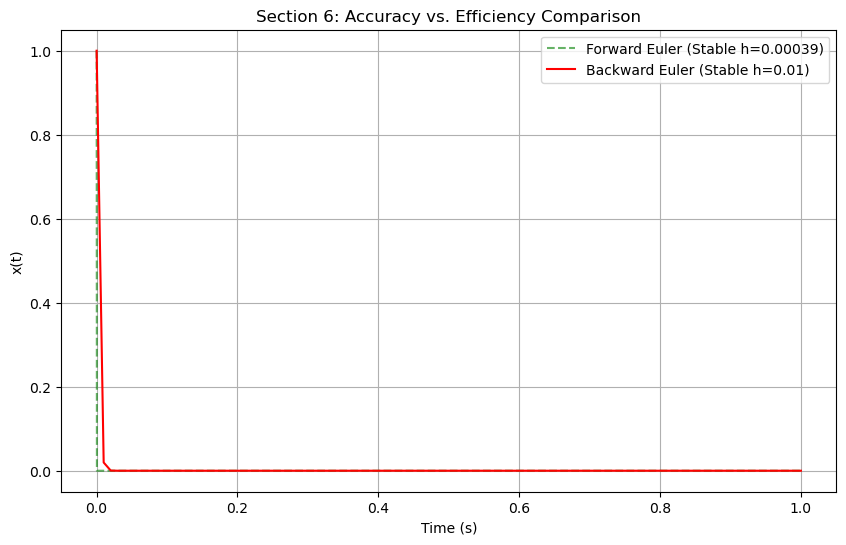

Forward Euler Steps: 2566
Backward Euler Steps: 101
Efficiency Gain: 25.4x fewer steps for Backward Euler


In [26]:
#Backward Euler with a large, efficient step size
h_back = 0.01 
t_back, x_back, _ = euler_backward(1.0, 0.0, 1.0, h_back)

#Forward Euler with the maximum stable step size (calculated in Section 2)
h_forw = 0.00039
t_forw, x_forw = euler_method(f, 1.0, 0.0, 1.0, h_forw)

#Create the comparison plot
plt.figure(figsize=(10, 6))
plt.plot(t_forw, x_forw, 'g--', label=f'Forward Euler (Stable h={h_forw})', alpha=0.6)
plt.plot(t_back, x_back, 'r-', label=f'Backward Euler (Stable h={h_back})')

plt.title("Section 6: Accuracy vs. Efficiency Comparison")
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

#print the cost comparison
print(f"Forward Euler Steps: {len(t_forw)}")
print(f"Backward Euler Steps: {len(t_back)}")
print(f"Efficiency Gain: {len(t_forw)/len(t_back):.1f}x fewer steps for Backward Euler")

# Section 6: Performance Analysis
As seen above, to get a stable solution, the explicit forward euler method must have a very small step size, requiring far more iterations than the implicit backward euler method, 25.4 times more iterations to be exact. The forward euler also does not necessarily provide more "useful" information than the backward euler method for the slow moving sine portion of the graph, even if it may be more accurate in the initial fast transient. However, the backward euler still maintains the integrity of the solution while providing a massive 25x efficiency gain, so I would consider it to be the winner in the accuracy-efficiency tradeoff. The two methods are also almost identical in cost per iteration since the Newton-Raphson solver converges in one step every time, giving another win to backward euler since it is not more exensive than forward euler, maintaining its efficiency gains. I would recommend using implicit methods like the backward euler method for applications such as this due to their ability to maintain a stable solution at far larger, more efficient, step sizes.

# Section 7: Conclusions
I analyzed a highly overdamped mechanical system with a high stiffness ratio of 5,000:1 using both explicit and implicit methods. I found that explicit methods like forward euler are practically unstable for such systems, requiring a very small maximum step size of $h < 0.0004$ to maintain stability, leading to high computational cost. In comparison, implicit methods like backward euler coupled with Newton-Raphson iteration remain stable at large step sizes like $h=0.5$, making them much more efficient for such systems.

Explicit methods are ideal for non-stiff equations where time scales are uniform, in these cases they are computationally cheap per step as they do not require solving algebraic equations. Implicit methods are ideal for stiff ODEs. They require more work per step, but their ability to use larger step sizes makes them much more efficient overall.

I have learned that for stiff systems, the Newton-Raphson solver is very efficient, converging in one iteration. This project highlighted that in engineering applications selying on a standard solver without checking stability criteria can cause extreme numerical failures. Identifying and using the fastest time scale of a system ($\tau = 1/|\lambda|$) will be essential going forward.